In [1]:
import numpy as np
import emcee 
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

In [50]:
transient = np.load('transient.npy')
# time = transient[:, 0]
# flux = transient[:, 1]
# errs = transient[:, 2]

time, flux, errs = transient.T

In [103]:
def mymodel(params, t):
    b, t0, A, alpha = params
    y = np.zeros(len(t))
    cond = t<t0
    y[cond] += b
    y[~cond] += b+A*np.exp(-alpha*(t[~cond]-t0))
    return y

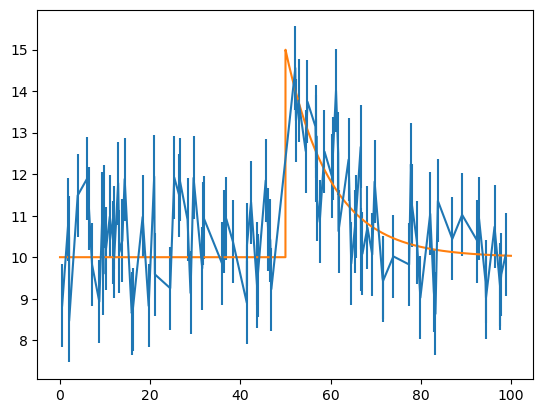

In [89]:
test_params = (10, 50, 5, 0.1)
xarr = np.linspace(0, 100, 10000)
fig, ax = plt.subplots()
plt.errorbar(time, flux, yerr=errs)
plt.plot(xarr, mymodel(test_params, xarr))

In [97]:
def log_lik(params, datatable):
    
    times, fluxes, sigma_y = datatable.T
    y_fit = mymodel(params, times)
    
    return -0.5 * np.sum((fluxes-y_fit)**2 / sigma_y**2 ) 

def log_prior(params):
    b, t0, A, alpha = params
    zero = 0
    bmax = 50
    t0max = 100
    alphamin = np.exp(-5)
    alphamax = np.exp(5)

    if zero < b < bmax and zero < A < bmax and zero < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 - np.log(alpha)

    else:
        return -np.inf

def log_post(params, datatable):
    return log_lik(params, datatable) + log_prior(params)

In [99]:
nsteps = 20000
nparams = 4
nwalkers = 20
starting_guesses = test_params + 0.1*np.random.randn(nwalkers, nparams)

In [104]:
sampler = emcee.EnsembleSampler(nwalkers, nparams, log_post, args=[transient])
sampler.run_mcmc(starting_guesses, nsteps);

In [105]:
tau = sampler.get_autocorr_time()
print(tau)

[59.64520627 78.57924883 81.71526135 67.6826171 ]
